In [45]:
from headers import *
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import numpy as np
from utils.custom_train_test_split import custom_train_test_split, per_year_train_test_split
import os
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold
from sklearn.svm import SVC, LinearSVC, LinearSVR
from sklearn.metrics import classification_report, make_scorer, confusion_matrix
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from joblib import dump, load
from IPython.display import Markdown, display
from math import sqrt
import json
import warnings
warnings.filterwarnings('ignore')

In [46]:
files = ['../data/deduplicated/combined_inner_ticker.csv']
trainDf, testDf = custom_train_test_split(files)
X_train = trainDf[ratioKeys + relativeRatioKeys]
X_test = testDf[ratioKeys + relativeRatioKeys]

In [47]:
# y_train = trainDf['alpha1Year']
# y_test = testDf['alpha1Year']
# 
# regr = Pipeline([
#     ('scaler', StandardScaler()),
#     ('svr', LinearSVR(random_state=0, tol=1e-5))
# ])
# regr.fit(X_train, y_train)
# regr.score(X_test, y_test)

In [48]:
grids = {}
for yLabel in yAlpha:
    print(yLabel)
    y_train = trainDf[yLabel]
    y_test = testDf[yLabel]

    pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('svr', LinearSVR(random_state=997))
        ])
    params = [
        {
            'svr__C': [0.1, 0.5, 1.0, 5.0],
            'svr__epsilon': [0.0, 0.1, 0.5],
            'svr__tol': [1e-5, 1e-4, 1e-3]
        }
    ]
    grid = GridSearchCV(pipeline,
                params,
                cv=KFold(3),
                verbose=1,
                refit=True,
                n_jobs=-1,
                scoring='r2',
                error_score='raise'
                )
    grid.fit(X_train, y_train)
    #
    grids[yLabel] = grid
    print(grid.score(X_test, y_test))


alpha1Year
Fitting 3 folds for each of 36 candidates, totalling 108 fits
-0.010801909437490265
adjustedAlpha1Year
Fitting 3 folds for each of 36 candidates, totalling 108 fits
-0.008735037284939073
equalAlpha1Year
Fitting 3 folds for each of 36 candidates, totalling 108 fits
-0.00690446664645239
equalAdjustedAlpha1Year
Fitting 3 folds for each of 36 candidates, totalling 108 fits
-0.0046592001769090174
alpha2Year
Fitting 3 folds for each of 36 candidates, totalling 108 fits
-0.009798523484051413
adjustedAlpha2Year
Fitting 3 folds for each of 36 candidates, totalling 108 fits
-0.007739035552514206
equalAlpha2Year
Fitting 3 folds for each of 36 candidates, totalling 108 fits
-0.006941583526642425
equalAdjustedAlpha2Year
Fitting 3 folds for each of 36 candidates, totalling 108 fits
-0.004282863736828402


In [50]:
results = {}

for yLabel in yAlpha:
    grid = grids[yLabel]
    y_pred = grid.predict(X_test)
    thresholds = [99, 98, 95, 90, 80, 70]
    results[yLabel] = {}
    results[yLabel]['mean'] = []
    results[yLabel]['median'] = []
    for threshold in thresholds:
        barrier = np.percentile(y_pred, threshold)
        y_pred_threshold = y_pred >= barrier

        xTakenThreshold = X_test[y_pred_threshold]
        takenDataThreshold = testDf.loc[testDf.index.intersection(xTakenThreshold.index)]
        print(f'% of True taken with threshold {threshold} adjustment -  {takenDataThreshold.loc[:, yLabel].count()}')
        print(
            f'For threshold data - mean was {round(takenDataThreshold.loc[:, yLabel].mean() * 100, 2)}%, median was {round(takenDataThreshold.loc[:, yLabel].median() * 100, 2)}%')
        results[yLabel]['mean'].append(takenDataThreshold.loc[:, yLabel].mean())
        results[yLabel]['median'].append(takenDataThreshold.loc[:, yLabel].median())


% of True taken with threshold 99 adjustment -  67
For threshold data - mean was 10.03%, median was 1.26%
% of True taken with threshold 98 adjustment -  133
For threshold data - mean was 11.66%, median was 1.7%
% of True taken with threshold 95 adjustment -  331
For threshold data - mean was 8.7%, median was 0.09%
% of True taken with threshold 90 adjustment -  662
For threshold data - mean was 10.37%, median was -0.8%
% of True taken with threshold 80 adjustment -  1323
For threshold data - mean was 11.13%, median was 0.45%
% of True taken with threshold 70 adjustment -  1985
For threshold data - mean was 9.89%, median was 0.48%
% of True taken with threshold 99 adjustment -  67
For threshold data - mean was 11.33%, median was 7.74%
% of True taken with threshold 98 adjustment -  133
For threshold data - mean was 14.75%, median was 6.14%
% of True taken with threshold 95 adjustment -  331
For threshold data - mean was 13.57%, median was 1.51%
% of True taken with threshold 90 adjustm

In [52]:
files = ['../data/deduplicated/combined_inner_ticker.csv']
trainDf, testDf = per_year_train_test_split(files, format='%Y-%m-%d')
X_train = trainDf[ratioKeys + relativeRatioKeys]
X_test = testDf[ratioKeys + relativeRatioKeys]

In [53]:
gridsPerYear = {}
for yLabel in yAlpha:
    print(yLabel)
    y_train = trainDf[yLabel]
    y_test = testDf[yLabel]

    pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('svr', LinearSVR(random_state=997))
        ])
    params = [
        {
            'svr__C': [0.1, 0.5, 1.0, 5.0],
            'svr__epsilon': [0.0, 0.1, 0.5],
            'svr__tol': [1e-5, 1e-4, 1e-3]
        }
    ]
    grid = GridSearchCV(pipeline,
                params,
                cv=KFold(3),
                verbose=1,
                refit=True,
                n_jobs=-1,
                scoring='r2',
                error_score='raise'
                )
    grid.fit(X_train, y_train)
    #
    gridsPerYear[yLabel] = grid
    print(grid.score(X_test, y_test))


alpha1Year
Fitting 3 folds for each of 36 candidates, totalling 108 fits
-0.03858600281146041
adjustedAlpha1Year
Fitting 3 folds for each of 36 candidates, totalling 108 fits
-0.060991233285960345
equalAlpha1Year
Fitting 3 folds for each of 36 candidates, totalling 108 fits
-0.045100495271896746
equalAdjustedAlpha1Year
Fitting 3 folds for each of 36 candidates, totalling 108 fits
-0.04136919941716943
alpha2Year
Fitting 3 folds for each of 36 candidates, totalling 108 fits
-0.01443600210738527
adjustedAlpha2Year
Fitting 3 folds for each of 36 candidates, totalling 108 fits
0.0022580862047966166
equalAlpha2Year
Fitting 3 folds for each of 36 candidates, totalling 108 fits
-0.03243106624423553
equalAdjustedAlpha2Year
Fitting 3 folds for each of 36 candidates, totalling 108 fits
-0.004921769857383129


In [54]:
resultsPerYear = {}
thresholds = [99, 98, 95, 90, 80, 70]

for yLabel in yAlpha:
    grid = gridsPerYear[yLabel]
    y_pred = grid.predict(X_test)
    resultsPerYear[yLabel] = {}
    resultsPerYear[yLabel]['mean'] = []
    resultsPerYear[yLabel]['median'] = []
    for threshold in thresholds:
        barrier = np.percentile(y_pred, threshold)
        y_pred_threshold = y_pred >= barrier

        xTakenThreshold = X_test[y_pred_threshold]
        takenDataThreshold = testDf.loc[testDf.index.intersection(xTakenThreshold.index)]
        print(f'% of True taken with threshold {threshold} adjustment -  {takenDataThreshold.loc[:, yLabel].count()}')
        print(
            f'For threshold data - mean was {round(takenDataThreshold.loc[:, yLabel].mean() * 100, 2)}%, median was {round(takenDataThreshold.loc[:, yLabel].median() * 100, 2)}%')
        resultsPerYear[yLabel]['mean'].append(takenDataThreshold.loc[:, yLabel].mean())
        resultsPerYear[yLabel]['median'].append(takenDataThreshold.loc[:, yLabel].median())


% of True taken with threshold 99 adjustment -  106
For threshold data - mean was 3.29%, median was -11.07%
% of True taken with threshold 98 adjustment -  212
For threshold data - mean was 2.01%, median was -7.08%
% of True taken with threshold 95 adjustment -  528
For threshold data - mean was 1.06%, median was -5.37%
% of True taken with threshold 90 adjustment -  1056
For threshold data - mean was 3.68%, median was -1.58%
% of True taken with threshold 80 adjustment -  2112
For threshold data - mean was 4.72%, median was -0.4%
% of True taken with threshold 70 adjustment -  3167
For threshold data - mean was 4.22%, median was -0.06%
% of True taken with threshold 99 adjustment -  106
For threshold data - mean was 5.93%, median was -4.0%
% of True taken with threshold 98 adjustment -  212
For threshold data - mean was 5.46%, median was 1.77%
% of True taken with threshold 95 adjustment -  528
For threshold data - mean was 2.74%, median was -2.32%
% of True taken with threshold 90 ad

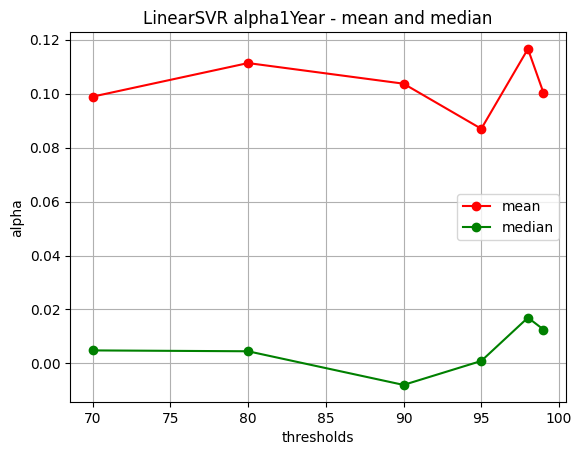

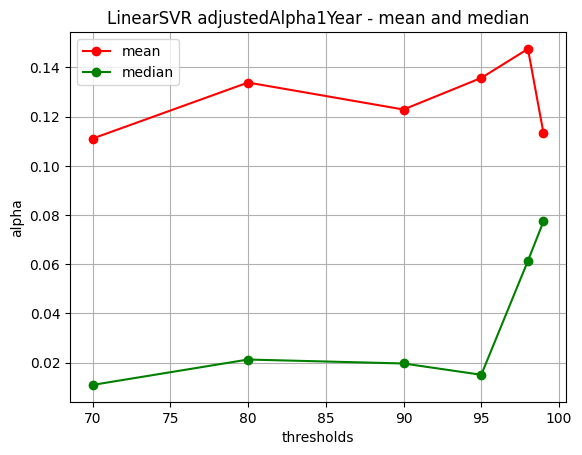

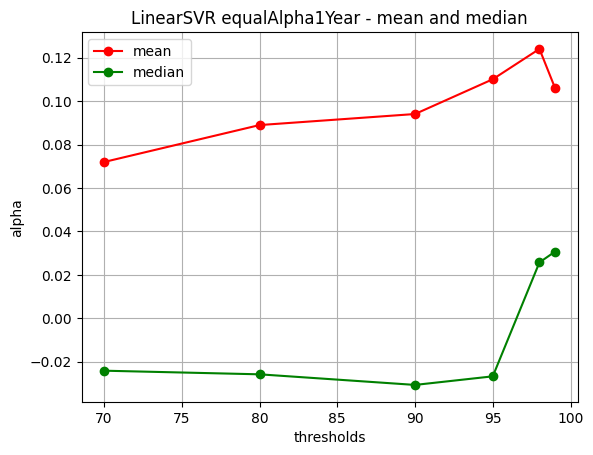

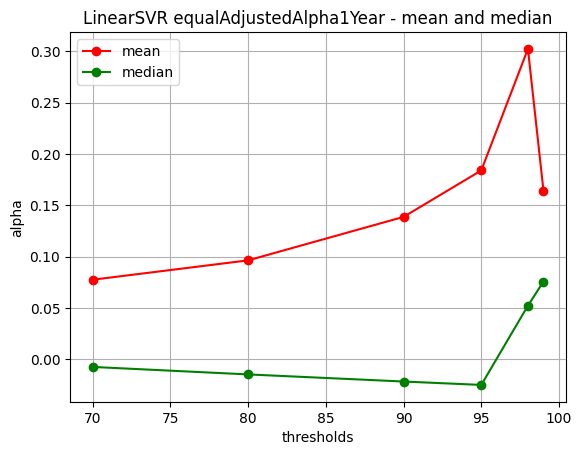

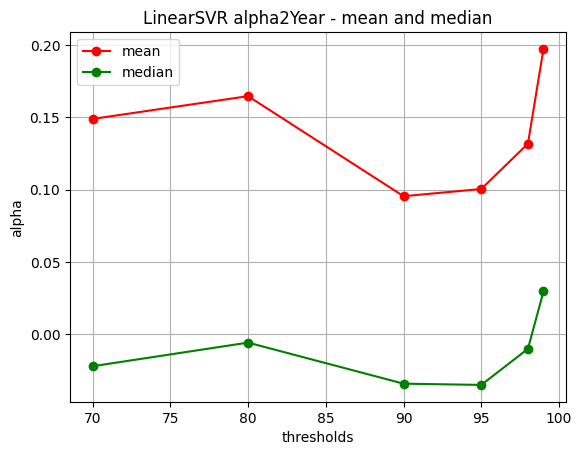

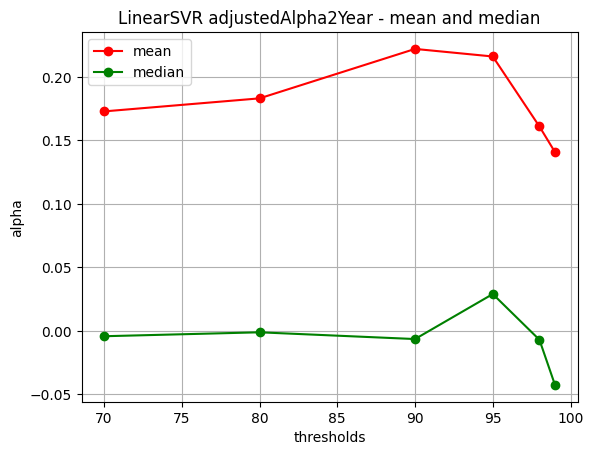

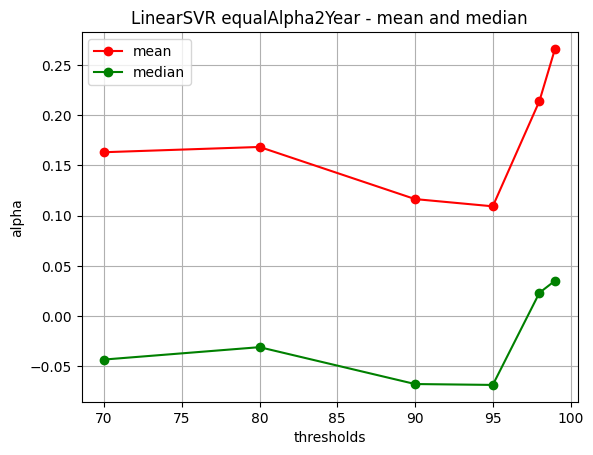

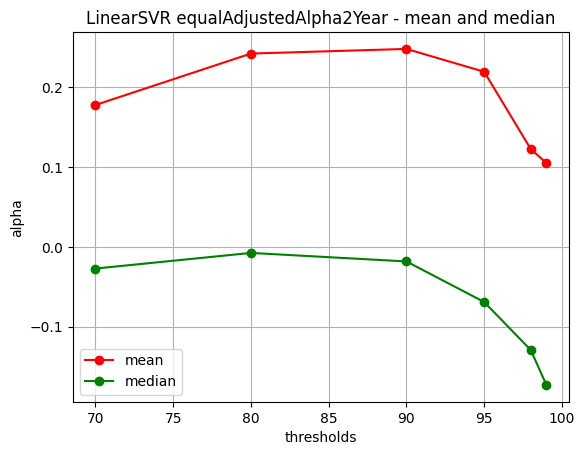

In [56]:
for yLabel in yAlpha:
    data = results[yLabel]
    plt.plot(thresholds, data['mean'], marker='o', linestyle='-', color='r', label='mean')
    plt.plot(thresholds, data['median'], marker='o', linestyle='-', color='green', label='median')

    plt.xlabel('thresholds')
    plt.ylabel('alpha')
    plt.title(f'LinearSVR {yLabel} - mean and median')
    plt.grid(True)
    plt.legend()

    plt.show()

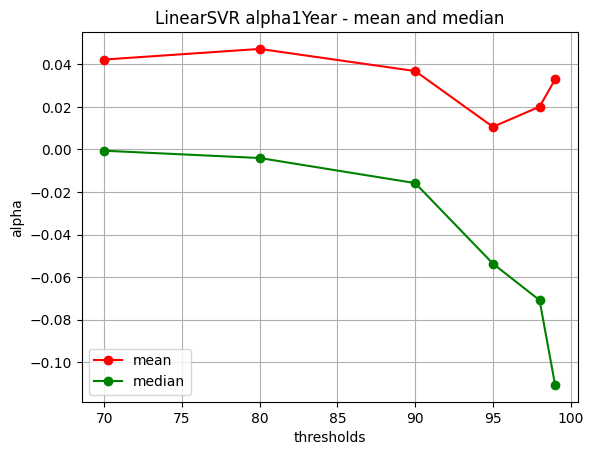

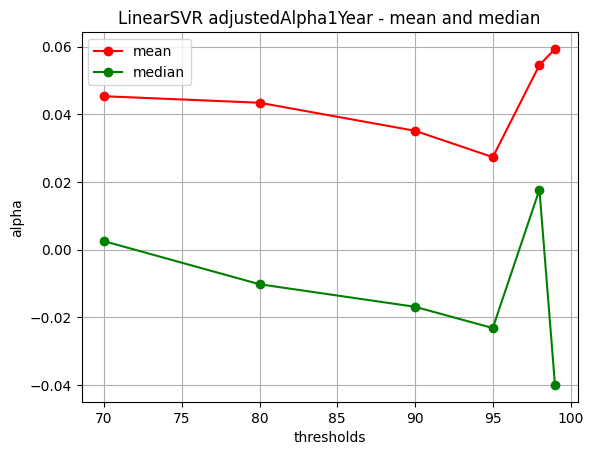

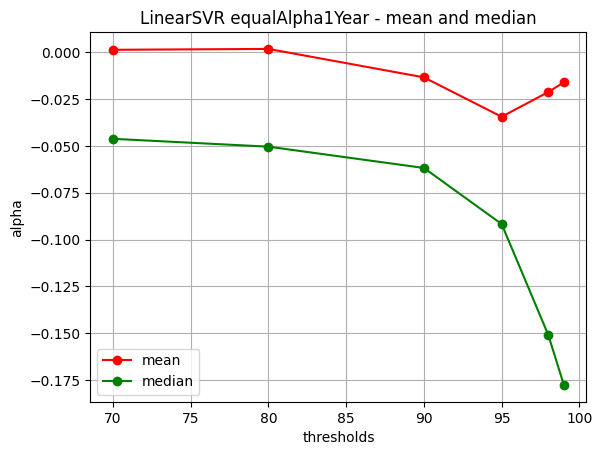

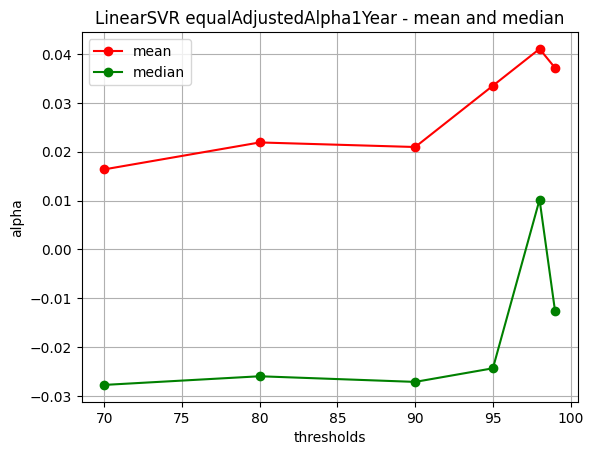

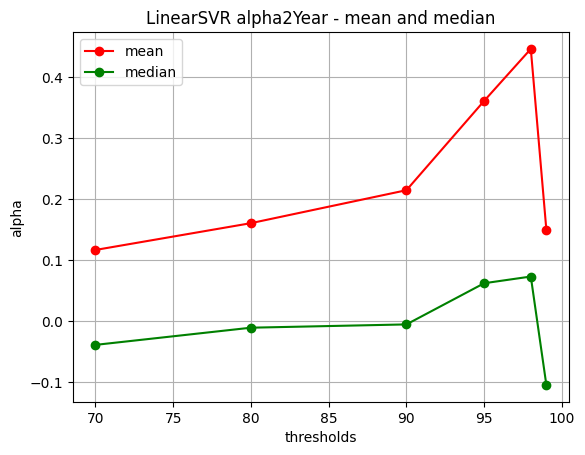

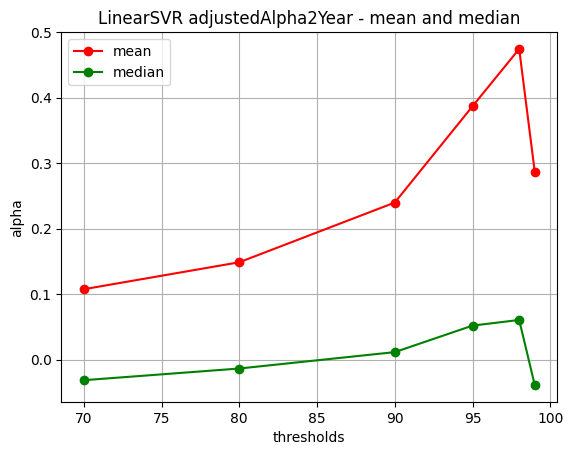

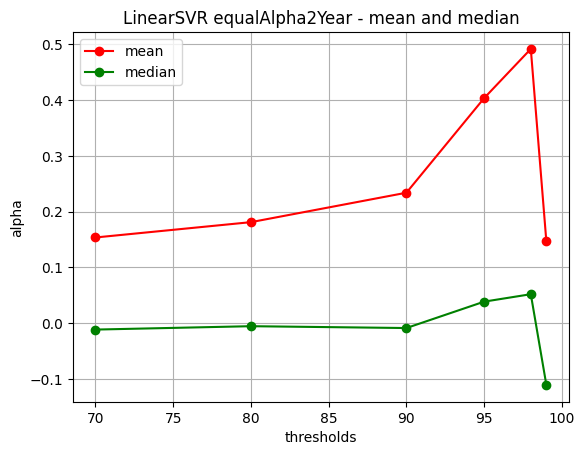

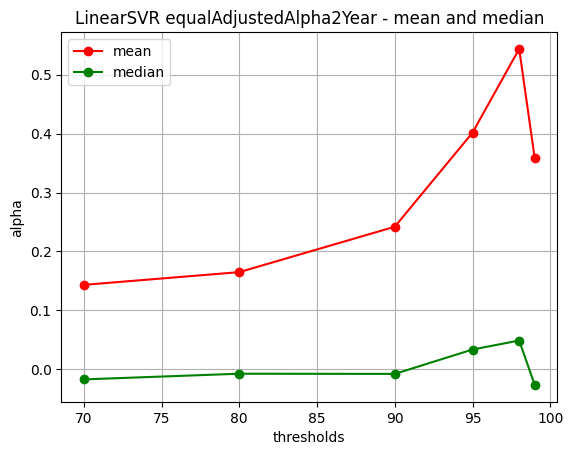

In [57]:
for yLabel in yAlpha:
    data = resultsPerYear[yLabel]
    plt.plot(thresholds, data['mean'], marker='o', linestyle='-', color='r', label='mean')
    plt.plot(thresholds, data['median'], marker='o', linestyle='-', color='green', label='median')

    plt.xlabel('thresholds')
    plt.ylabel('alpha')
    plt.title(f'LinearSVR {yLabel} - mean and median')
    plt.grid(True)
    plt.legend()

    plt.show()